# Week 9 Phase 2 — Temporal melt-pool width dynamics
This teaching notebook reads the frozen generated artifacts; the experimental engine lives in `src/week9_phase2_temporal_width_dynamics.py`.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd().parents[1] if Path.cwd().name == 'week_09' else Path.cwd()
OUT = ROOT / 'outputs' / 'week9_phase2_temporal_width_dynamics'
assert OUT.is_dir()


## Axis-semantics correction
Forensic review found that the first published run used ΔX while calling it width. The authoritative extractor defines ΔX as longitudinal length and ΔY as transverse width. This corrected notebook uses W(t)=Ymax−Ymin.


In [2]:
display(pd.read_csv(OUT/'axis_semantics_audit.csv'))


,quantity,formula,physical_interpretation,authoritative_source_file,authoritative_source_line_or_function,semantic_source_verified,numeric_files_checked,numeric_mapping_verified,status
0,longitudinal_length,x_max - x_min,longitudinal melt-pool length ΔX,src\week7_phase2_sph_v2_physical_target_extrac...,POSITION_BOUNDS_COLUMNS; extract_experiment: l...,True,5,True,PASS
1,transverse_width,y_max - y_min,transverse melt-pool width ΔY,src\week7_phase2_sph_v2_physical_target_extrac...,POSITION_BOUNDS_COLUMNS; extract_experiment: w...,True,5,True,PASS


## Ioan's question
Does transverse width growth, not scan speed or longitudinal length, distinguish eventual Keyhole tracks and add information beyond the pre-process score h?


In [3]:
display(pd.read_csv(OUT/'width_temporal_features.csv').head())


,experiment_name,population_row_index,has_keyhole,P,VX,LS,ST,log_h,W_initial_um,W_max_um,...,L_early_dWdt_20_um_per_ms,L_early_dWdt_40_um_per_ms,L_gain_20_um,L_gain_40_um,L_time_to_50pct_max_tau,L_robust_max_positive_dWdt_um_per_ms,L_robust_median_positive_dWdt_um_per_ms,L_robust_early_dWdt_20_um_per_ms,L_robust_early_dWdt_40_um_per_ms,L_robust_time_of_max_dWdt_tau
0,P-102p928146519_VX-0p633805217924_LS-5p2939436...,0,0,102.928147,0.633805,0.000053,318.223787,19.631581,4.0,127.644275,...,-1071.678390,-1479.657308,168.375208,248.401473,0.155,1298.494859,250.220180,580.702391,413.171469,0.000
1,P-109p741517589_VX-0p915030812968_LS-7p9975966...,1,0,109.741518,0.915031,0.000080,303.804431,18.893203,4.0,127.360793,...,-1161.722014,-1176.116040,172.440800,256.641287,0.165,1977.719939,343.696460,817.041035,623.755056,0.000
2,P-111p098510779_VX-0p492021331775_LS-4p8010846...,2,0,111.098511,0.492021,0.000048,345.911754,19.981159,4.0,137.070591,...,-184.719642,-873.540662,157.935842,245.602131,0.170,940.785979,221.090056,430.792814,358.154540,0.000
3,P-113p729503671_VX-0p646987288946_LS-8p2808888...,3,0,113.729504,0.646987,0.000083,328.878079,19.050000,4.0,158.662190,...,-1278.808600,-1244.109574,178.353328,264.060103,0.165,1393.772846,217.064716,582.545913,460.227685,0.000
4,P-115p973342836_VX-0p629021136955_LS-5p8169479...,4,0,115.973343,0.629021,0.000058,308.264474,19.613380,4.0,137.967163,...,-1168.943364,-1318.844311,171.630368,262.884862,0.175,1162.406132,254.887489,560.897201,449.915844,0.005


## Corrected W(t)
The pinned monitor columns are x_min, x_max, y_min, y_max, z_min, z_max. Canonical width is ΔY in metres, shown in micrometres. Cooling-only rows are excluded.


,category,count,keyhole_count,conduction_count,P_mean,VX_mean,LS_mean,ST_mean,standardized_mean_difference_usable_minus_missing
0,missing_or_unusable_width_time_series,55,3.0,52.0,161.906568,0.628640,0.000064,338.651082,NaN
1,valid_width_time_series,350,70.0,280.0,213.635364,0.622156,0.000062,350.564439,NaN
2,structured_missingness_P,405,NaN,NaN,NaN,NaN,NaN,NaN,0.545516
3,structured_missingness_VX,405,NaN,NaN,NaN,NaN,NaN,NaN,-0.027695
4,structured_missingness_LS,405,NaN,NaN,NaN,NaN,NaN,NaN,-0.132172
5,structured_missingness_ST,405,NaN,NaN,NaN,NaN,NaN,NaN,0.379458


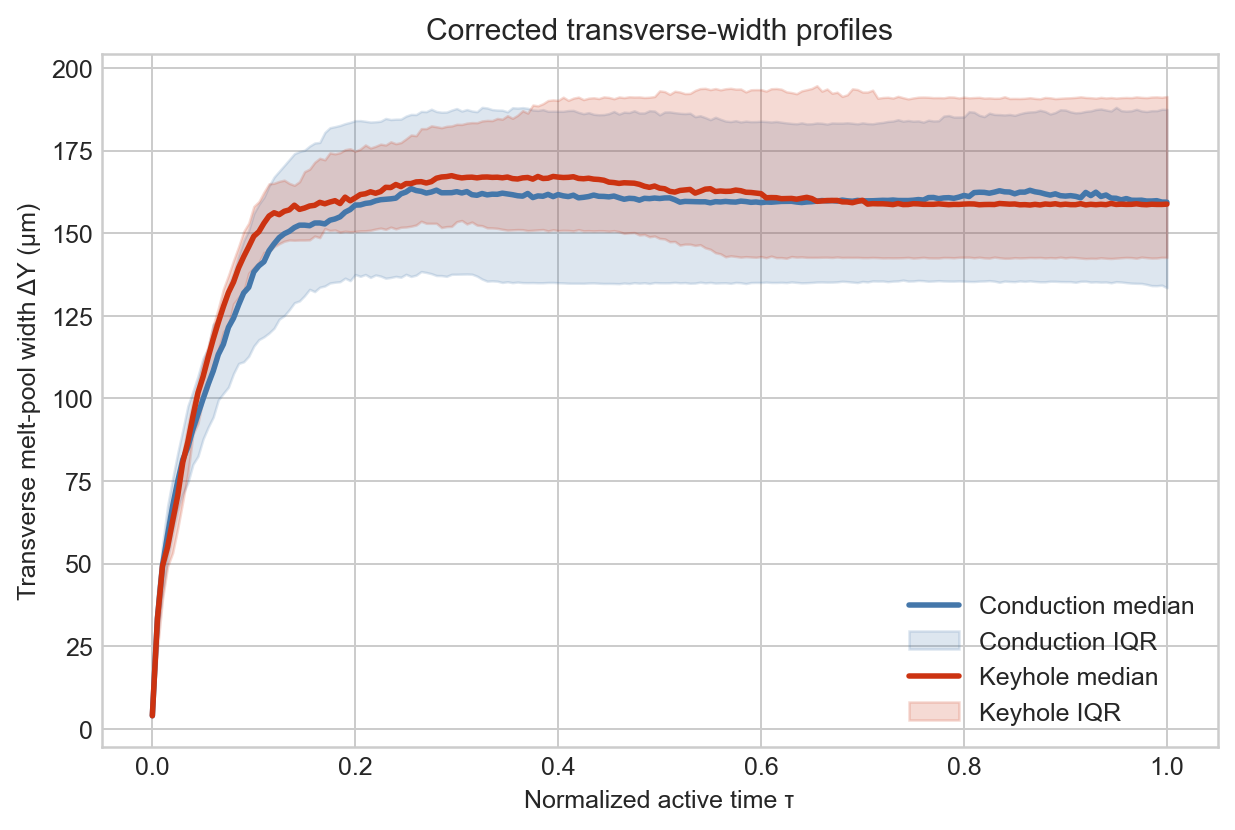

In [4]:
display(pd.read_csv(OUT/'width_missingness_audit.csv')); display(Image(filename=OUT/'figures'/'02_class_width_profiles.png'))


## Corrected dW/dt
The timestamp-only regularity gate selects centered finite differences. A fixed five-grid-point local-linear slope is the non-tuned robustness derivative. Units are µm/ms.


,derivative_claim,raw_feature,robust_feature,raw_cliffs_delta,robust_cliffs_delta,direction_consistent,robust_effect_fraction_of_raw,robust_median_difference_ci_low,robust_median_difference_ci_high,status
0,maximum positive derivative,max_positive_dWdt_um_per_ms,robust_max_positive_dWdt_um_per_ms,-0.058418,-0.229592,True,3.930131,-982.532335,-54.486602,ROBUST
1,median positive derivative,median_positive_dWdt_um_per_ms,robust_median_positive_dWdt_um_per_ms,-0.090204,-0.265612,True,2.944570,-11.363806,-4.035356,ROBUST
2,early 20% derivative,early_dWdt_20_um_per_ms,robust_early_dWdt_20_um_per_ms,0.550612,0.104898,True,0.190511,-34.773882,61.321992,QUALIFIED
3,early 40% derivative,early_dWdt_40_um_per_ms,robust_early_dWdt_40_um_per_ms,0.495765,-0.015714,False,0.031697,-12.139788,27.745698,UNSTABLE
4,time of derivative peak,time_of_max_dWdt_tau,robust_time_of_max_dWdt_tau,-0.099949,-0.015459,True,0.154671,0.000000,0.000000,QUALIFIED


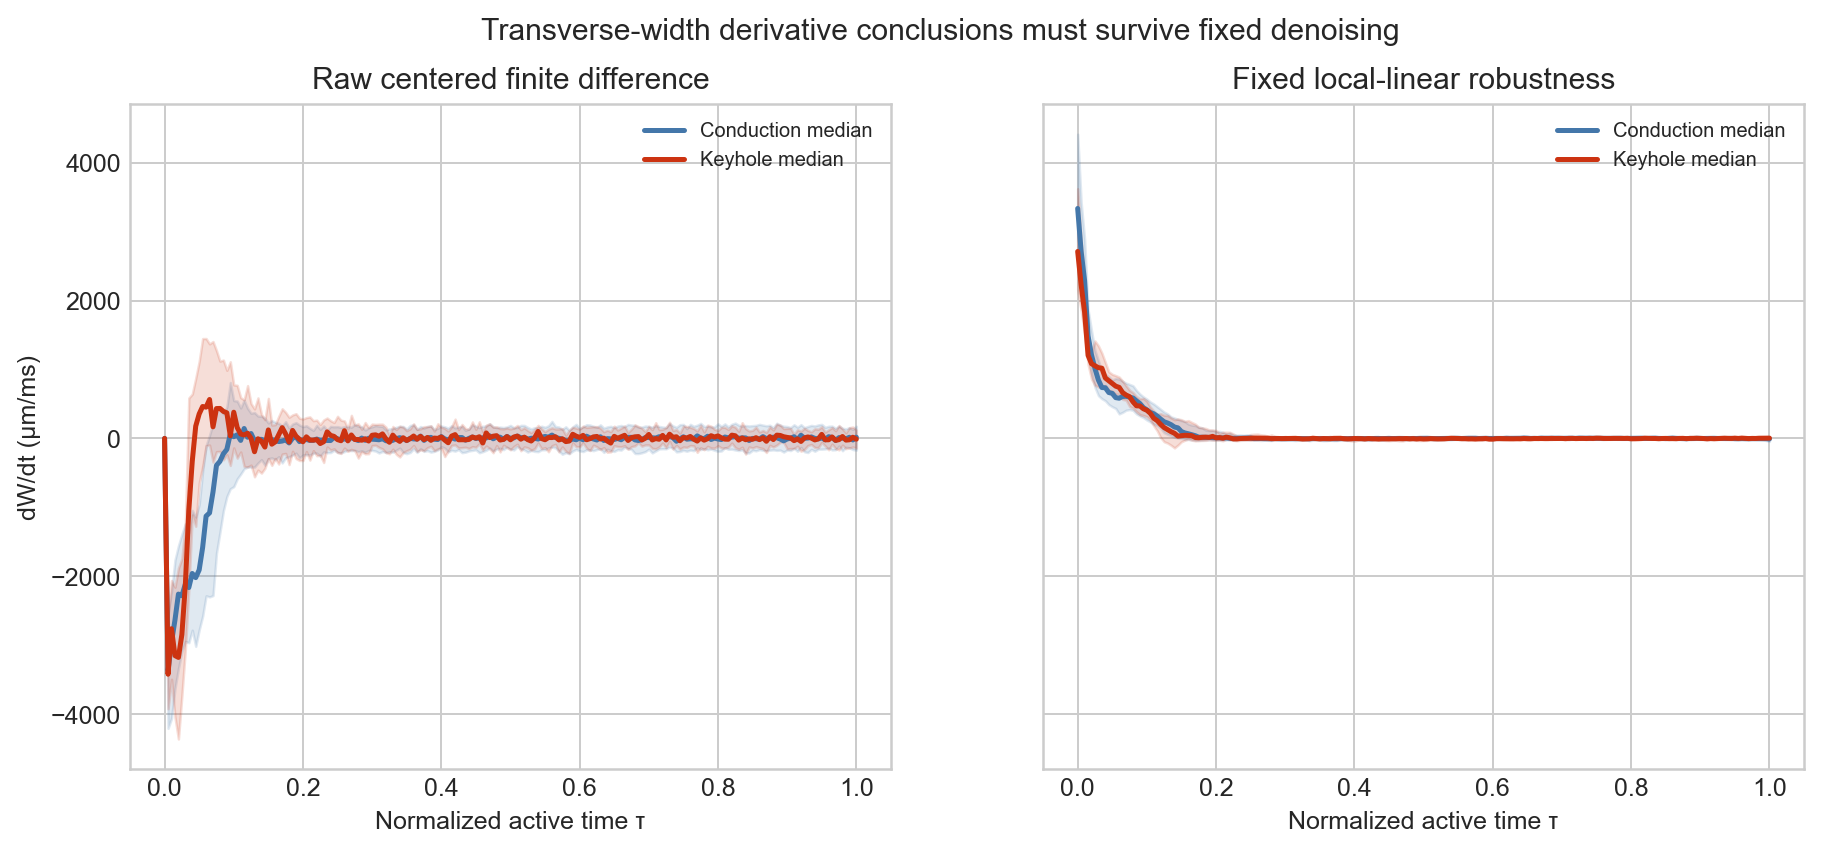

In [5]:
display(pd.read_csv(OUT/'derivative_robustness_gate.csv')); display(Image(filename=OUT/'figures'/'03_class_derivative_profiles.png'))


## Temporal profiles
Medians and IQRs show both class differences and overlap.


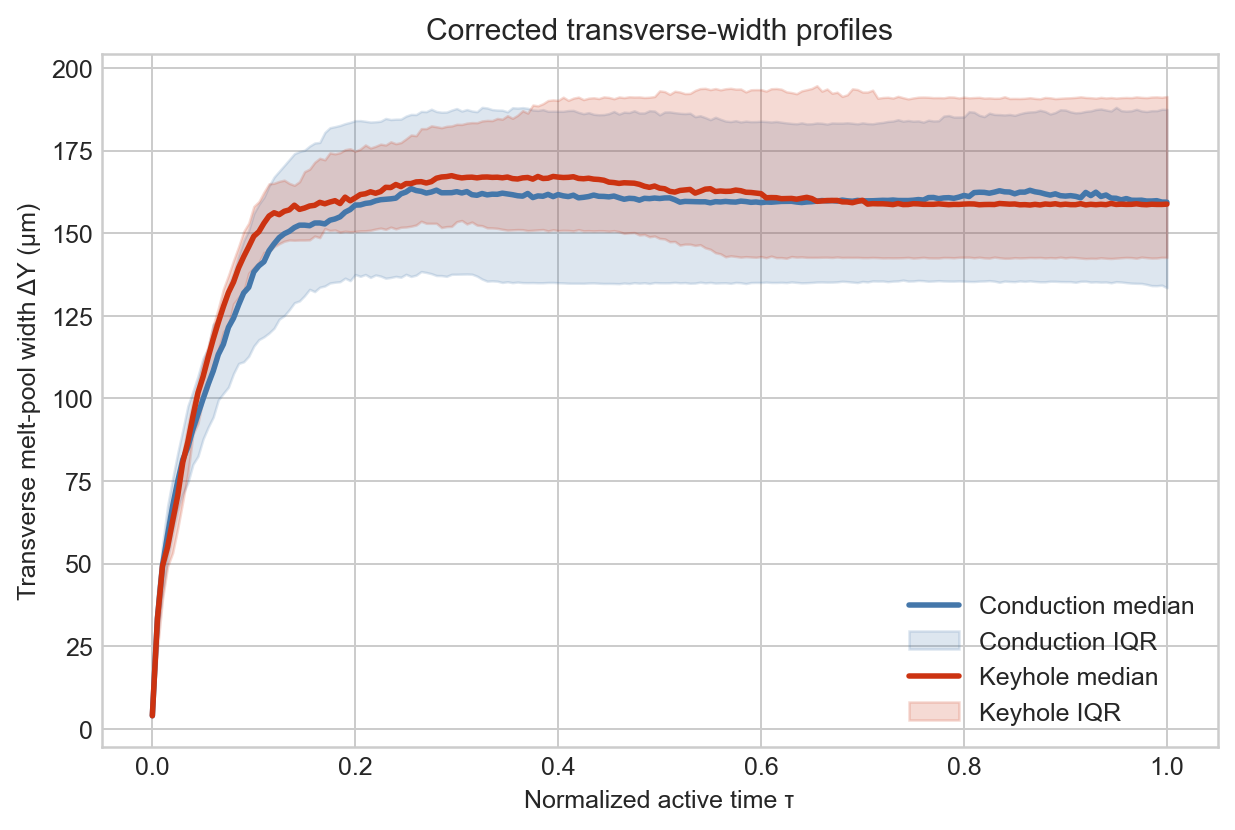

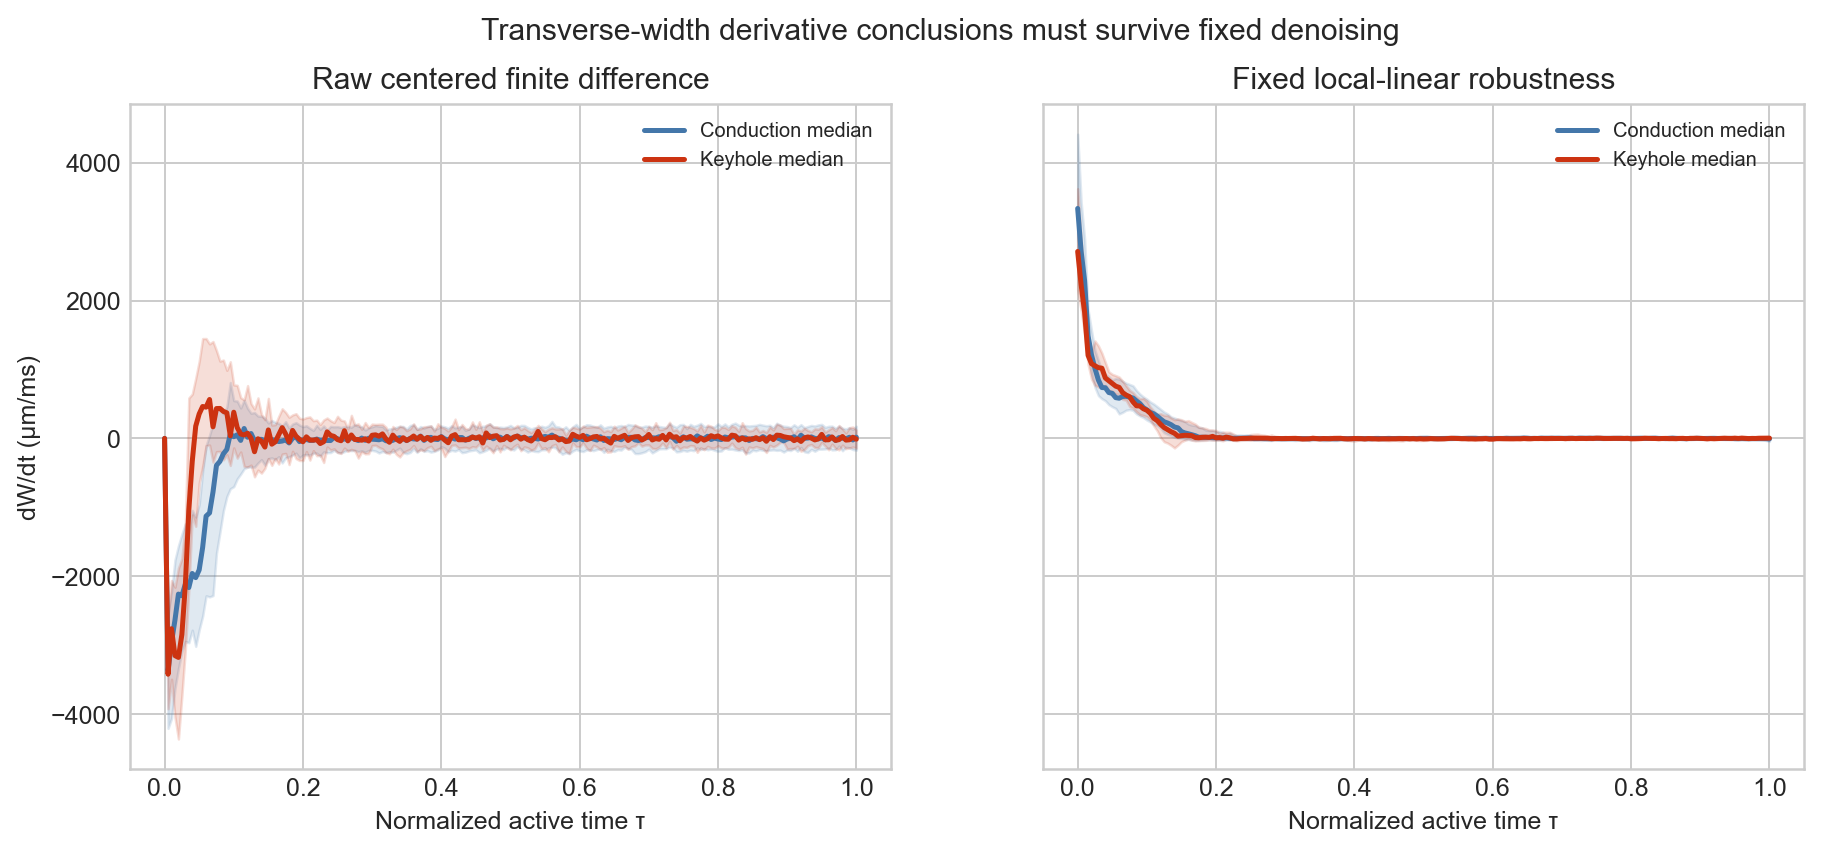

In [6]:
display(Image(filename=OUT/'figures'/'02_class_width_profiles.png')); display(Image(filename=OUT/'figures'/'03_class_derivative_profiles.png'))


## Temporal feature effects
Primary models use non-derivative shape features and the fixed robust derivative features. Raw finite differences remain descriptive only.


In [7]:
display(pd.read_csv(OUT/'static_feature_effects.csv').sort_values('cliffs_delta', key=abs, ascending=False))


,feature,feature_group,conduction_n,keyhole_n,conduction_median,keyhole_median,median_difference_keyhole_minus_conduction,median_difference_ci_low,median_difference_ci_high,cliffs_delta,spearman_rho_with_label,spearman_p,holm_p
9,early_dWdt_20_um_per_ms,raw_derivative,280,70,-205.417197,-57.880503,147.536694,100.978089,199.611987,0.550612,0.381479,1.438565e-13,2.301703e-12
10,early_dWdt_40_um_per_ms,raw_derivative,280,70,-63.465846,-16.945463,46.520382,32.464859,68.242568,0.495765,0.343485,3.973827e-11,5.960740e-10
12,robust_median_positive_dWdt_um_per_ms,robust_derivative,280,70,26.834972,19.511285,-7.323687,-11.363806,-4.035356,-0.265612,-0.184022,5.401334e-04,7.561867e-03
5,time_to_50pct_max_width_tau,shape,280,70,0.035000,0.035000,0.000000,0.000000,0.010000,0.243112,0.170039,1.407822e-03,1.830168e-02
11,robust_max_positive_dWdt_um_per_ms,robust_derivative,280,70,3335.335356,2711.531417,-623.803939,-982.532335,-54.486602,-0.229592,-0.159067,2.842841e-03,3.411409e-02
1,W_max_um,static,280,70,174.829403,174.534538,-0.294865,-7.894213,15.886745,0.162347,0.112478,3.542935e-02,3.897228e-01
4,width_gain_40_um,shape,280,70,157.677041,162.963469,5.286428,-6.899313,18.452527,0.150714,0.104418,5.095735e-02,5.095735e-01
3,width_gain_20_um,shape,280,70,154.530055,156.707416,2.177361,-4.533434,12.844160,0.119388,0.082715,1.224526e-01,1.000000e+00
13,robust_early_dWdt_20_um_per_ms,robust_derivative,280,70,382.613240,401.165835,18.552595,-34.773882,61.321992,0.104898,0.072676,1.749182e-01,1.000000e+00
8,time_of_max_dWdt_tau,raw_derivative,280,70,0.075000,0.065000,-0.010000,-0.025000,0.007500,-0.099949,-0.069278,1.960158e-01,1.000000e+00


## PCA
PCA uses the same corrected robust temporal representation as the model, without labels. It is a descriptive projection, not feature importance or a physical manifold.


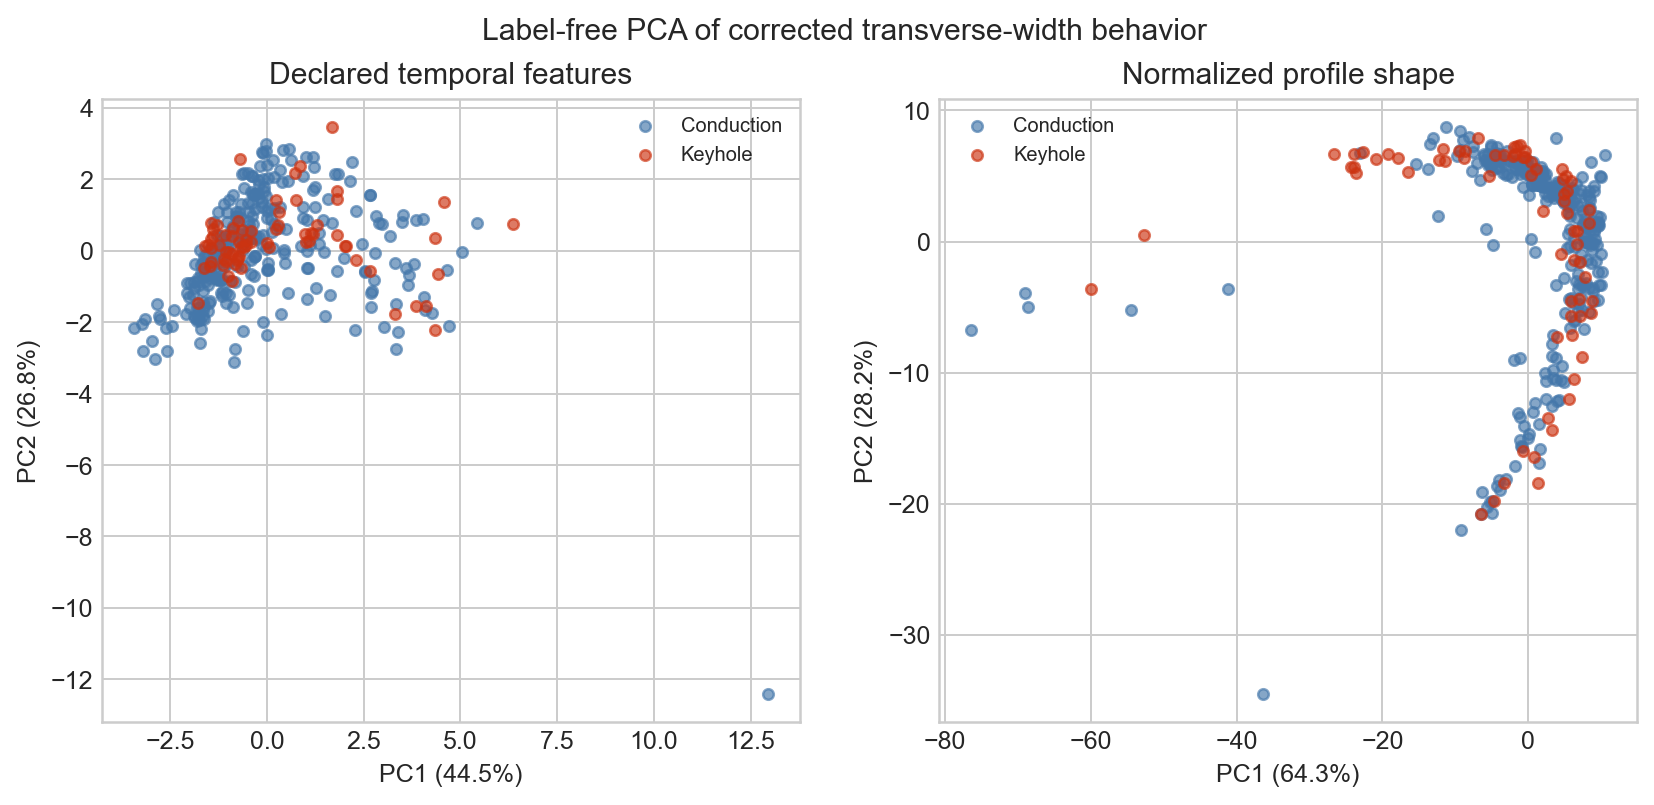

,feature,PC1_loading,PC2_loading
0,width_gain_20_um,0.189443,0.612949
1,width_gain_40_um,0.371222,0.458745
2,time_to_50pct_max_width_tau,0.493755,-0.144990
3,robust_max_positive_dWdt_um_per_ms,-0.328776,0.083461
4,robust_median_positive_dWdt_um_per_ms,0.394589,-0.272134
5,robust_early_dWdt_20_um_per_ms,0.180280,0.416146
6,robust_early_dWdt_40_um_per_ms,0.478940,-0.155239
7,robust_time_of_max_dWdt_tau,0.238396,-0.338416


In [8]:
display(Image(filename=OUT/'figures'/'05_temporal_width_pca.png')); display(pd.read_csv(OUT/'pca_loadings.csv'))


## Leak-free models
Scalers and logistic coefficients are fitted inside each frozen training fold. B1/q20/q30 are evaluation-only.


,model,subset,metric,mean,sd_across_repeats,repeat_blocks
0,h_only,full,roc_auc,0.989401,0.000962,20
1,h_only,full,pr_auc,0.953460,0.007421,20
2,h_only,full,accuracy,0.961857,0.003502,20
3,h_only,full,balanced_accuracy,0.929286,0.005130,20
4,h_only,full,keyhole_recall,0.875000,0.009124,20
...,...,...,...,...,...,...
130,width_dynamics,q30,keyhole_recall,0.012059,0.013684,20
131,width_dynamics,q30,conduction_recall,0.995862,0.007897,20
132,width_dynamics,q30,false_negative,37.000000,1.169795,20
133,width_dynamics,q30,false_positive,0.300000,0.571241,20


,subset,contrast,metric,mean_difference,ci_low,ci_high,repeat_blocks
0,full,h_plus_width_dynamics - h_only,roc_auc,0.000569,-0.000949,0.001809,20
1,full,h_plus_width_dynamics - h_only,pr_auc,0.009105,0.005488,0.013043,20
2,full,h_plus_width_dynamics - h_only,accuracy,-0.004000,-0.006286,-0.001857,20
3,full,h_plus_width_dynamics - h_only,balanced_accuracy,-0.018304,-0.022768,-0.013929,20
4,full,h_plus_width_dynamics - h_only,keyhole_recall,-0.042143,-0.050714,-0.033571,20
5,full,h_plus_width_dynamics - h_only,conduction_recall,0.005536,0.004107,0.007143,20
6,full,h_plus_width_dynamics - h_only,false_negative,2.950000,2.350000,3.550000,20
7,full,h_plus_width_dynamics - h_only,false_positive,-1.550000,-2.000000,-1.150000,20
8,full,h_plus_width_dynamics - h_only,brier_score,0.000665,-0.000057,0.001429,20
9,full,h_plus_width_shape_only - h_only,roc_auc,0.002862,0.002551,0.003194,20


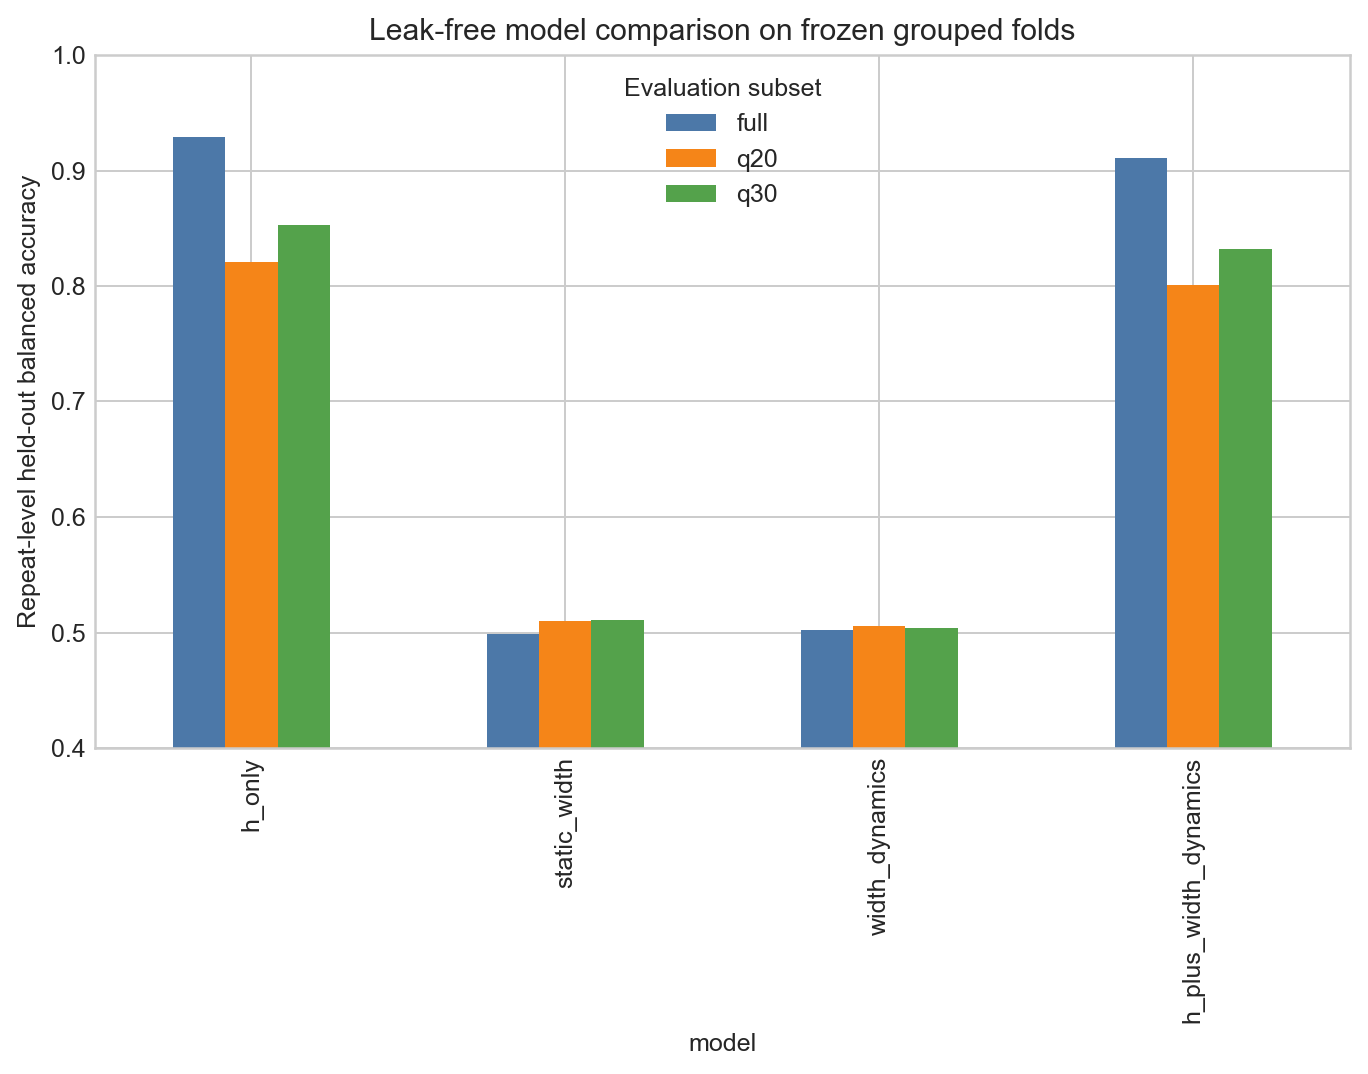

In [9]:
display(pd.read_csv(OUT/'model_oof_summary.csv')); display(pd.read_csv(OUT/'model_paired_contrasts.csv')); display(Image(filename=OUT/'figures'/'06_model_comparison.png'))


## Beyond h
Hard-decision metrics and ranking/probability metrics are interpreted separately.


,model,subset,metric,mean,sd_across_repeats,repeat_blocks
0,h_only,full,roc_auc,0.989401,0.000962,20
1,h_only,full,pr_auc,0.953460,0.007421,20
2,h_only,full,accuracy,0.961857,0.003502,20
3,h_only,full,balanced_accuracy,0.929286,0.005130,20
4,h_only,full,keyhole_recall,0.875000,0.009124,20
...,...,...,...,...,...,...
130,width_dynamics,q30,keyhole_recall,0.012059,0.013684,20
131,width_dynamics,q30,conduction_recall,0.995862,0.007897,20
132,width_dynamics,q30,false_negative,37.000000,1.169795,20
133,width_dynamics,q30,false_positive,0.300000,0.571241,20


,subset,contrast,metric,mean_difference,ci_low,ci_high,repeat_blocks
0,full,h_plus_width_dynamics - h_only,roc_auc,0.000569,-0.000949,0.001809,20
1,full,h_plus_width_dynamics - h_only,pr_auc,0.009105,0.005488,0.013043,20
2,full,h_plus_width_dynamics - h_only,accuracy,-0.004000,-0.006286,-0.001857,20
3,full,h_plus_width_dynamics - h_only,balanced_accuracy,-0.018304,-0.022768,-0.013929,20
4,full,h_plus_width_dynamics - h_only,keyhole_recall,-0.042143,-0.050714,-0.033571,20
5,full,h_plus_width_dynamics - h_only,conduction_recall,0.005536,0.004107,0.007143,20
6,full,h_plus_width_dynamics - h_only,false_negative,2.950000,2.350000,3.550000,20
7,full,h_plus_width_dynamics - h_only,false_positive,-1.550000,-2.000000,-1.150000,20
8,full,h_plus_width_dynamics - h_only,brier_score,0.000665,-0.000057,0.001429,20
9,full,h_plus_width_shape_only - h_only,roc_auc,0.002862,0.002551,0.003194,20


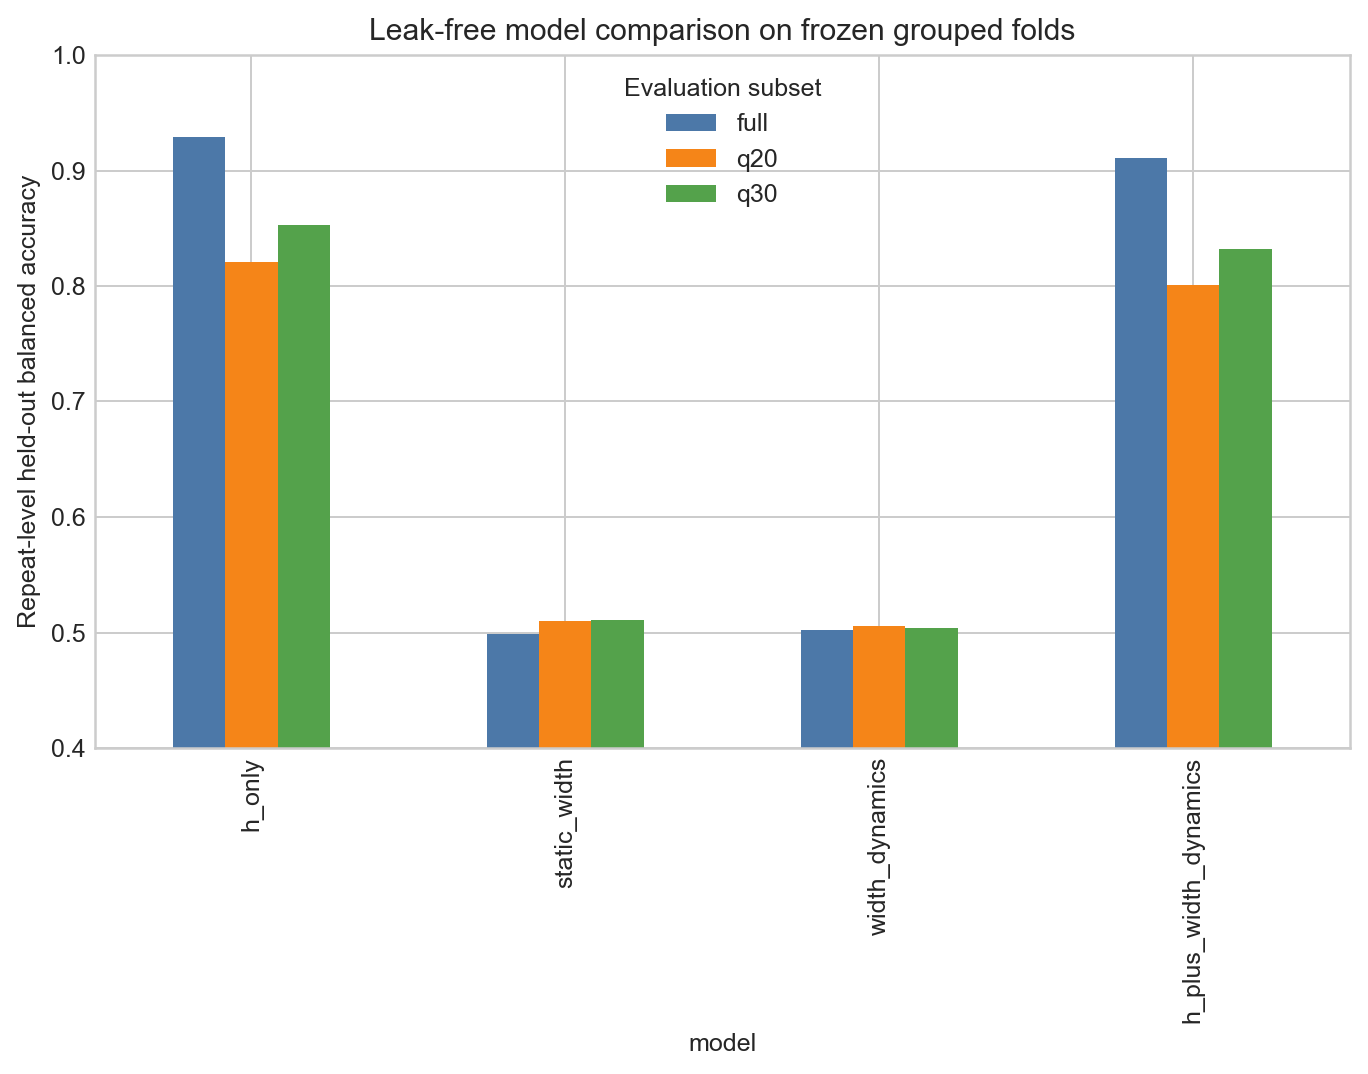

In [10]:
display(pd.read_csv(OUT/'model_oof_summary.csv')); display(pd.read_csv(OUT/'model_paired_contrasts.csv')); display(Image(filename=OUT/'figures'/'06_model_comparison.png'))


## Early prefixes
Each prefix model sees only transverse-width samples at or before the declared prefix and uses robust derivative summaries.


,subset,prefix_tau,contrast,metric,mean_difference,ci_low,ci_high,repeat_blocks
0,full,0.2,h_plus_width_history - h_only,roc_auc,0.001742,0.001326,0.002166,20
1,full,0.2,h_plus_width_history - h_only,pr_auc,0.010480,0.007943,0.013377,20
2,full,0.2,h_plus_width_history - h_only,accuracy,0.005286,0.003714,0.006857,20
3,full,0.2,h_plus_width_history - h_only,balanced_accuracy,0.005714,0.002411,0.008929,20
4,full,0.2,h_plus_width_history - h_only,keyhole_recall,0.006429,0.000000,0.012857,20
...,...,...,...,...,...,...,...,...
130,q30,1.0,h_plus_width_history - h_only,keyhole_recall,-0.012026,-0.023174,-0.001245,20
131,q30,1.0,h_plus_width_history - h_only,conduction_recall,0.013508,0.008731,0.018943,20
132,q30,1.0,h_plus_width_history - h_only,false_negative,0.450000,0.050000,0.900000,20
133,q30,1.0,h_plus_width_history - h_only,false_positive,-1.000000,-1.400000,-0.600000,20


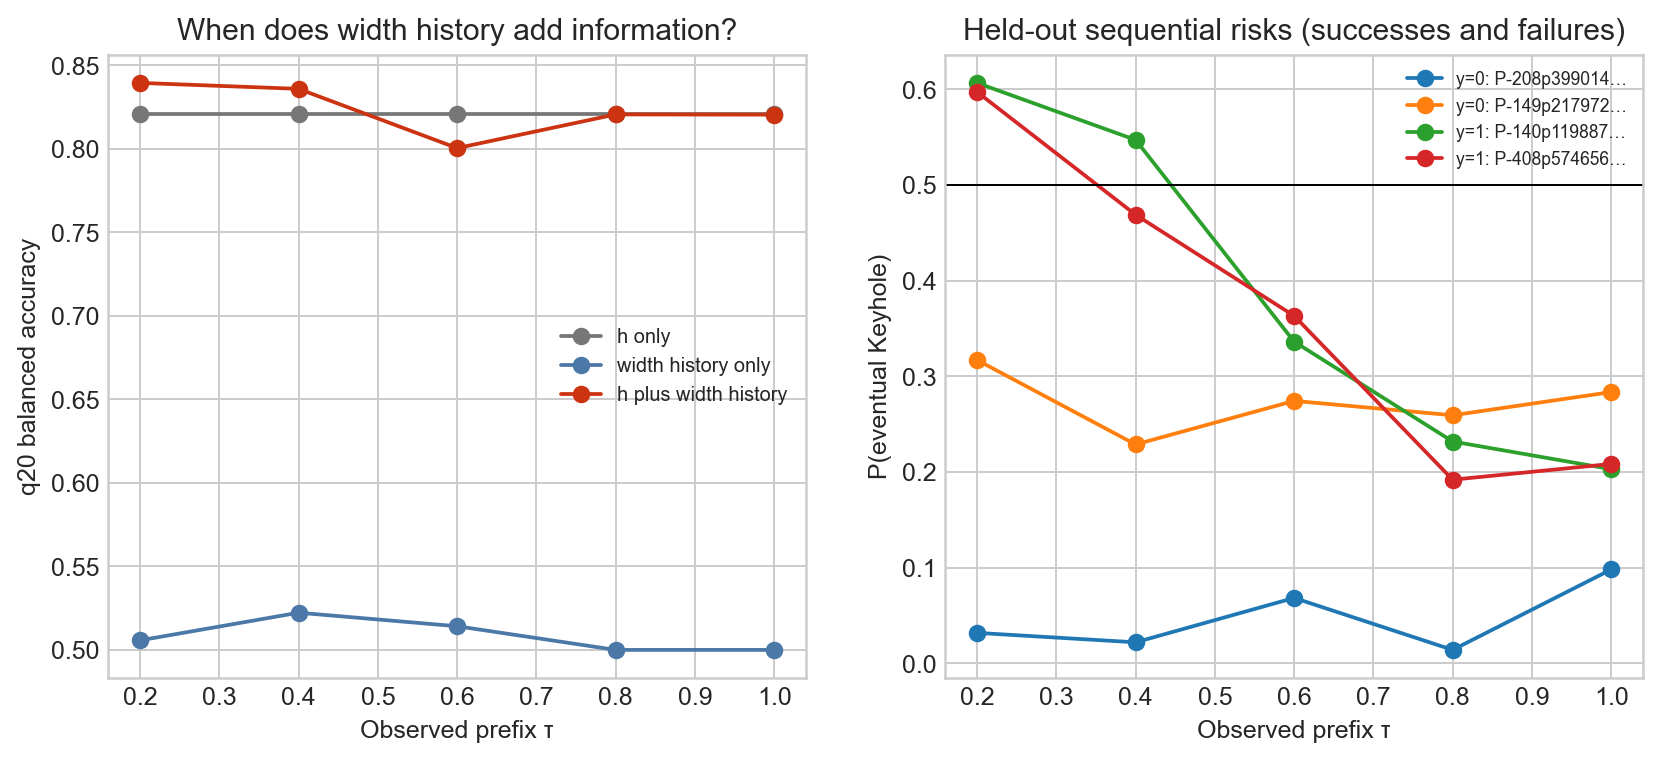

In [11]:
display(pd.read_csv(OUT/'prefix_model_contrasts.csv')); display(Image(filename=OUT/'figures'/'07_prefix_performance_and_risk.png'))


## First observed Keyhole
Exact manual-frame alignment supports descriptive timing relative to the first observed valid Keyhole frame, not continuous physical onset or a warning rule.


,experiment_name,has_keyhole,onset_available,first_keyhole_monitor_row_index,first_keyhole_time_s,first_keyhole_tau,peak_dWdt_tau,peak_minus_first_keyhole_ms,peak_precedes_first_observed_keyhole,robust_peak_dWdt_tau,robust_peak_minus_first_keyhole_ms,robust_peak_precedes_first_observed_keyhole
count,70,70.0,70,70.000000,70.000000,70.000000,70.000000,70.000000,70,70.000000,70.000000,70
unique,70,NaN,1,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,1
top,P-208p096600196_VX-0p256636148953_LS-4p5249238...,NaN,True,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,True
freq,1,NaN,70,NaN,NaN,NaN,NaN,NaN,64,NaN,NaN,70
mean,NaN,1.0,NaN,37514.400000,0.000682,0.244098,0.112500,-0.187834,NaN,0.001071,-0.349835,NaN
std,NaN,0.0,NaN,15578.483792,0.000283,0.154045,0.163063,0.266741,NaN,0.004247,0.224733,NaN
min,NaN,1.0,NaN,19474.000000,0.000354,0.111751,0.000000,-1.289266,NaN,0.000000,-1.315801,NaN
25%,NaN,1.0,NaN,25280.000000,0.000460,0.163861,0.036250,-0.264734,NaN,0.000000,-0.380700,NaN
50%,NaN,1.0,NaN,33118.500000,0.000602,0.204737,0.065000,-0.193314,NaN,0.000000,-0.252557,NaN
75%,NaN,1.0,NaN,45790.000000,0.000832,0.253552,0.108750,-0.127352,NaN,0.000000,-0.234186,NaN


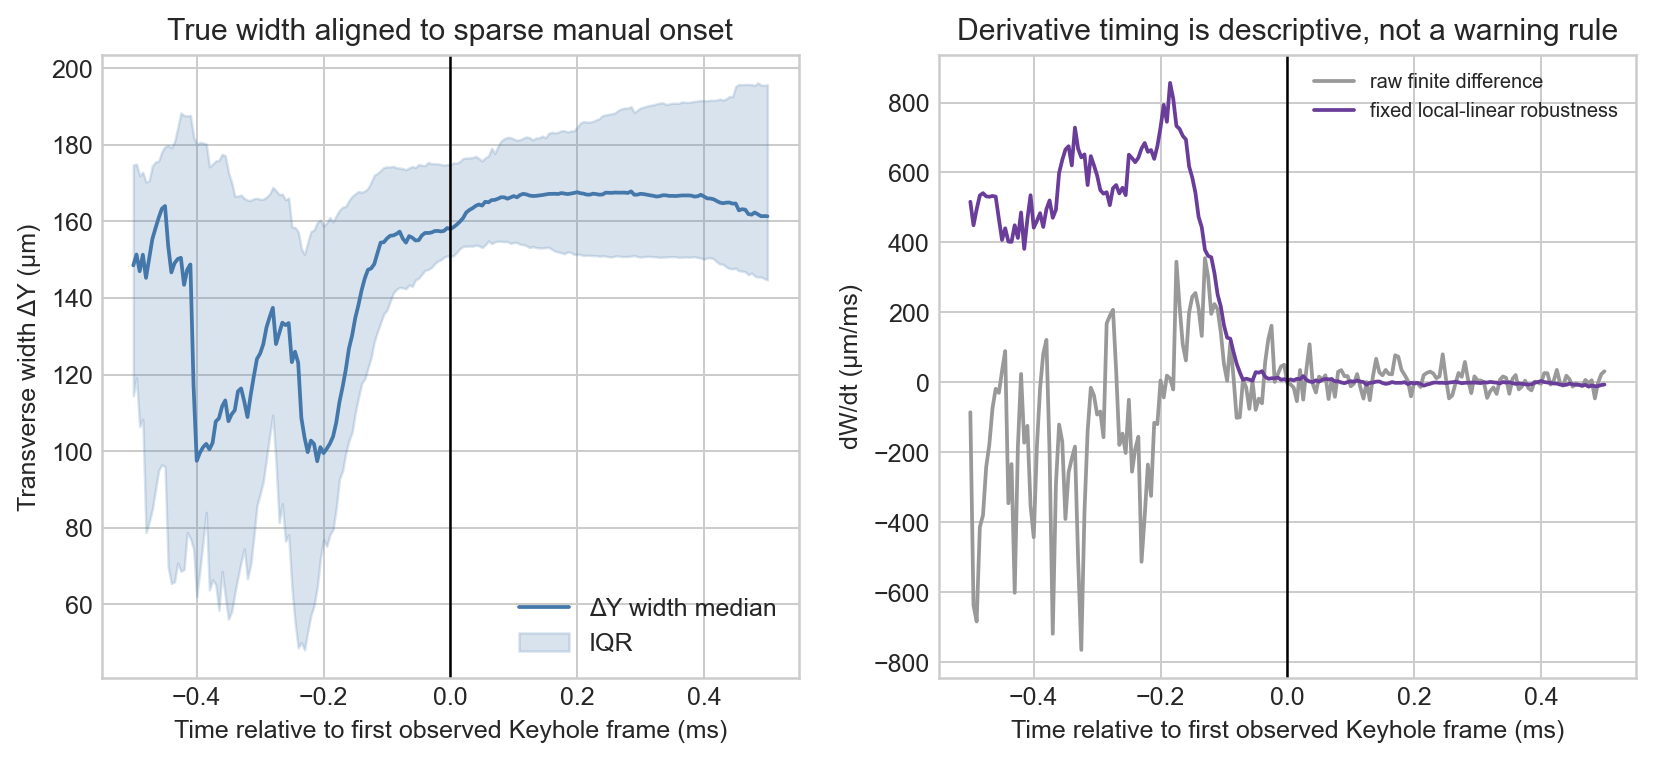

In [12]:
display(pd.read_csv(OUT/'keyhole_onset_audit.csv').query('onset_available == True').describe(include='all')); display(Image(filename=OUT/'figures'/'08_first_observed_keyhole_timing.png'))


## Longitudinal ΔX comparison
The former result is preserved as a secondary longitudinal-length diagnostic and is not presented as Ioan's width answer.


In [13]:
display(pd.read_csv(OUT/'longitudinal_vs_transverse_summary.csv'))


,axis_quantity,role,formula,model_feature_representation,static_max_conduction_median_um,static_max_keyhole_median_um,T0_conduction_median_um,T0_keyhole_median_um,time_to_50pct_conduction_median_tau,time_to_50pct_keyhole_median_tau,robust_early20_conduction_median_um_per_ms,robust_early20_keyhole_median_um_per_ms,full_width_dynamics_balanced_accuracy,q20_width_dynamics_balanced_accuracy,q20_width_dynamics_keyhole_recall,q20_h_plus_axis_dynamics_balanced_accuracy,strongest_effect_feature,strongest_effect_cliffs_delta,strongest_qualitative_conclusion
0,longitudinal_length_delta_X,secondary longitudinal diagnostic,x_max - x_min,published diagnostic used raw finite-differenc...,378.643072,552.486246,370.007587,511.455464,0.250,0.360,604.313469,474.856911,0.849554,0.733752,0.602393,0.789586,time_to_50pct_max_width_tau,0.827092,longitudinal ΔX carried strong regime structur...
1,transverse_width_delta_Y,canonical answer to Ioan's width question,y_max - y_min,corrected primary uses shape plus fixed robust...,174.829403,174.534538,161.118009,158.688932,0.035,0.035,382.613240,401.165835,0.502143,0.505360,0.015029,0.800879,time_to_50pct_max_width_tau,0.243112,transverse ΔY is the corrected canonical monit...


## Final safe conclusion
The generated reports state the corrected claim level and limitations.


In [14]:
print((OUT/'SUPERVISOR_PHASE2_ONE_PAGE.md').read_text(encoding='utf-8'))


# Supervisor Phase 2 — one page

## Correction and question
The authoritative extractor verifies **ΔX = longitudinal length** and **ΔY = transverse width**. The original Phase 2 accidentally answered the ΔX question. This correction answers Ioan using **W(t)=Ymax−Ymin=ΔY**.

## Corrected data and physical width
350/405 traces are usable (70 Keyhole, 280 Conduction). Median transverse Wmax is 174.5 µm for Keyhole versus 174.8 µm for Conduction; WT0 is 158.7 versus 161.1 µm. This is a descriptive effect; standalone hard classification is reported separately.

## Temporal feature and derivative robustness
The strongest deterministic shape/robust-derivative feature is `robust_median_positive_dWdt_um_per_ms`: Conduction median 26.8, Keyhole median 19.5 µm/ms (Cliff's delta -0.266). Raw early-20% dW/dt medians (Conduction, Keyhole) are -205.4, -57.9 µm/ms; fixed robust medians are 382.6, 401.2. Early-20% derivative gate: **QUALIFIED**. No faster/slower physical claim is made unless direction